In [1]:
import warnings
warnings.filterwarnings('ignore')   # keep the notebook output readable

import logging

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import rioxarray  # noqa: F401, registers the .rio accessor
import cartopy.crs as ccrs

import GRSl2bgen

logging.getLogger().setLevel(logging.WARNING)

# lighter figures for the documentation
%config InlineBackend.figure_formats = ['jpeg']
plt.rcParams['figure.dpi'] = 72

print(f'GRSl2bgen {GRSl2bgen.__version__}')

GRSl2bgen 1.0.0


In [2]:

l2a_path ='/data/satellite/Sentinel-2/subset/L2A/ambracian/2024/07/06/S2B_MSIL2A_20240706T091559_N0510_R093_T34SDJ_20240706T101118'

In [3]:
prod = GRSl2bgen.Product(l2a_path)
prod.raster

<xarray.Dataset> Size: 2GB
Dimensions:             (wl: 11, y: 3206, x: 4400)
Coordinates:
  * wl                  (wl) int64 88B 443 490 560 665 705 ... 842 865 1610 2190
    time                datetime64[ns] 8B ...
  * x                   (x) float64 35kB 4.728e+05 4.728e+05 ... 5.097e+05
  * y                   (y) float64 26kB 4.331e+06 4.331e+06 ... 4.299e+06
    central_wavelength  (wl) float32 44B dask.array<chunksize=(11,), meta=np.ndarray>
    spatial_ref         int64 8B ...
Data variables:
    Rrs                 (wl, y, x) float64 1GB dask.array<chunksize=(11, 1024, 1024), meta=np.ndarray>
    BRDFg               (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    aot550              (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    wind                (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    mask                (y, x) uint8 14MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    vza                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    sza                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    raa                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    flags               (y, x) int64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    dem                 (y, x) float64 113MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (12/73)
    long_name:                           CA BLUE GREEN RED VRE_1 VRE_2 VRE_3 ...
    constellation:                       Sentinel-2
    constellation_id:                    S2
    product_path:                        /data/satellite/Sentinel-2/L1C/34SDJ...
    product_name:                        S2B_MSIL1C_20240706T091559_N0510_R09...
    product_filename:                    S2B_MSIL1C_20240706T091559_N0510_R09...
    ...                                  ...
    vis_swir_index_threshold:            0.0
    hcld_threshold:                      0.003
    dirdata:                             /data/grs/grsdata
    abs_gas_file:                        /home/harmel/anaconda3/envs/py12/lib...
    water_vapor_transmittance_file:      /home/harmel/anaconda3/envs/py12/lib...
    metadata_profile:                    datacube

In [4]:
raster = prod.raster
crs = raster.rio.crs
str_epsg = str(crs)
zone = str_epsg[-2:]
is_south = str_epsg.split(':')[-1].startswith('327')   # EPSG:327xx = UTM south
proj = ccrs.UTM(zone, is_south)
x_res, y_res = raster.rio.resolution()
pixel_area = np.abs(x_res*y_res)
date = str(raster.time.dt.strftime('%Y/%m/%d').values)

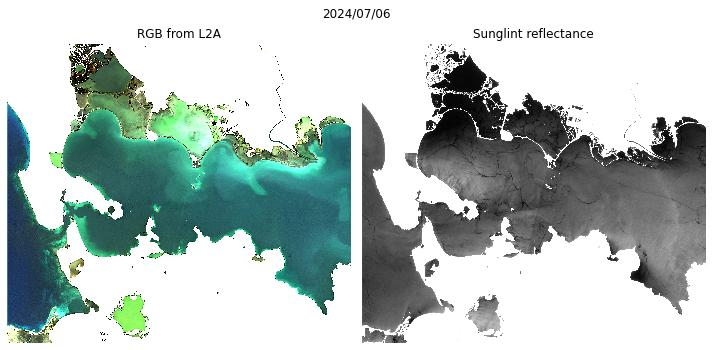

In [5]:


nrows=1
ncols=2
alpha=0.3
l2a_rgb = raster.Rrs.sel(wl= [670,565,490],method='nearest' )
fig,axs = plt.subplots(nrows,ncols,figsize=(ncols*5.,5*nrows),subplot_kw={'projection': proj}) 
fig.subplots_adjust(bottom=0.08, top=0.9, left=0.086, right=0.98,
                    hspace=0.05, wspace=0.07,)
if (ncols == 1) & (nrows == 1):
    axs = np.array([axs])
axs=axs.ravel()
[axi.set_axis_off() for axi in axs]   

ax=axs[0]


bcmap = mpl.colors.ListedColormap([(0,0,0,0),'green','blue'])
# omni_mask.plot.imshow(cmap=bcmap,alpha=alpha,add_colorbar=False,ax=ax)
l2a_rgb.plot.imshow(rgb='wl', robust=True,ax=ax)
raster['BRDFg'].plot.imshow(cmap=plt.cm.gray, robust=True,vmin=0,vmax=0.04,ax=axs[1],add_colorbar=False)
 

ax.set_title("RGB from L2A")
axs[1].set_title("Sunglint reflectance")

#cbar_ax = fig.add_axes([0.3, 0.0, 0.4, 0.02])  # Left, bottom, width, height.
#cbar = fig.colorbar(im, cax=cbar_ax, extend='both', orientation='horizontal')
#cbar.set_label('$SPM\ (mg\cdot L^{-1})$')
plt.suptitle(date)
plt.tight_layout()

In [6]:
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Spyrakos2018',Nclasses_to_be_saved=3)

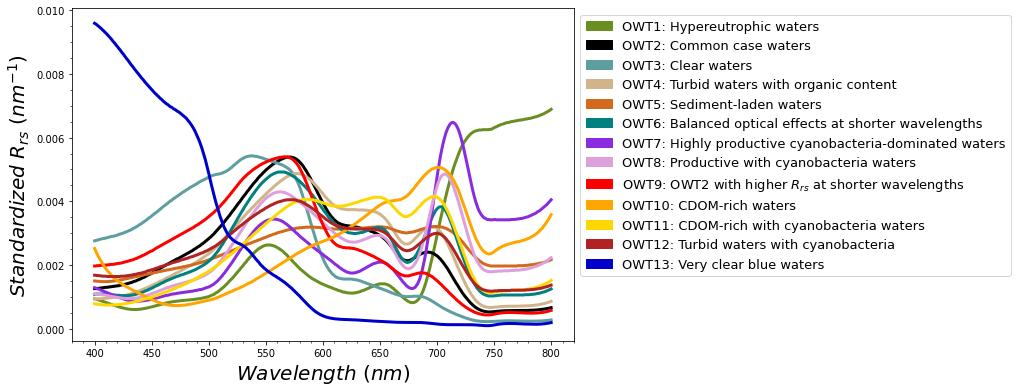

In [7]:
OWT.plot();

In [8]:
xowt_prod = OWT.multi_process()

In [9]:
xowt_prod

<xarray.Dataset> Size: 339MB
Dimensions:      (x: 4400, y: 3206, Nclasses: 3)
Coordinates:
    time         datetime64[ns] 8B 2024-07-06T09:15:59
  * x            (x) float64 35kB 4.728e+05 4.728e+05 ... 5.097e+05 5.097e+05
  * y            (y) float64 26kB 4.331e+06 4.331e+06 ... 4.299e+06 4.299e+06
    spatial_ref  int64 8B 0
  * Nclasses     (Nclasses) int64 24B 0 1 2
Data variables:
    owt_dist     (Nclasses, y, x) float32 169MB dask.array<chunksize=(3, 1024, 1024), meta=np.ndarray>
    owt_index    (Nclasses, y, x) float32 169MB dask.array<chunksize=(3, 1024, 1024), meta=np.ndarray>

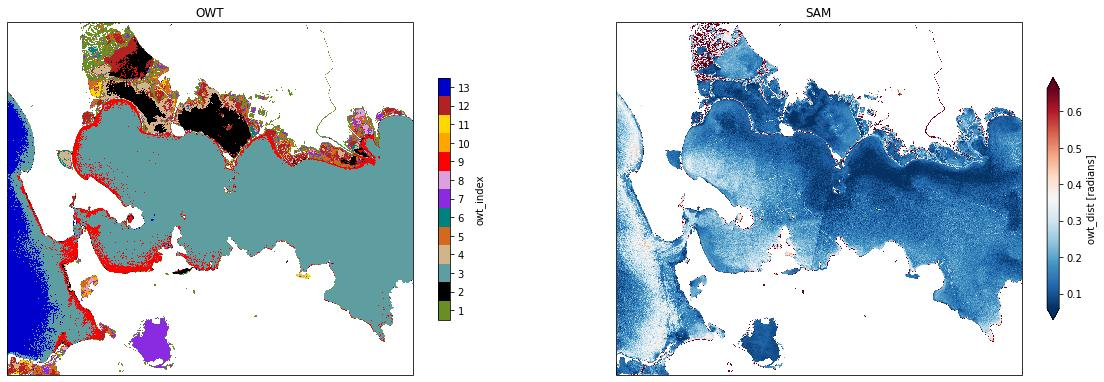

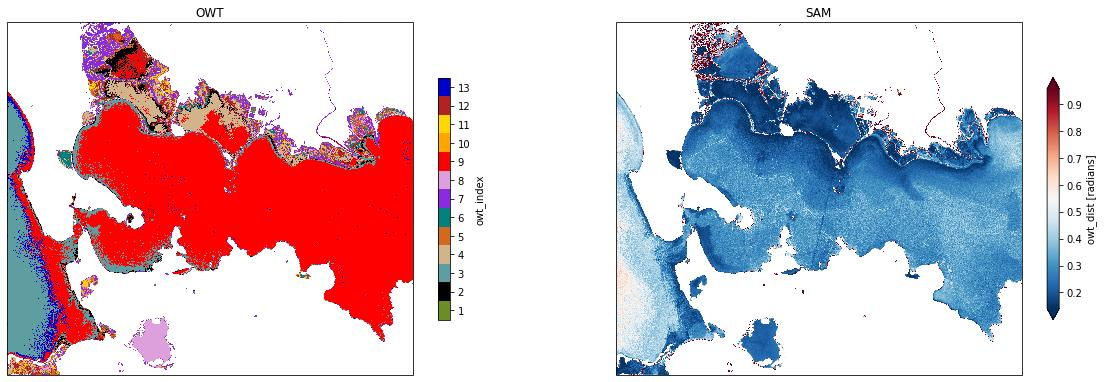

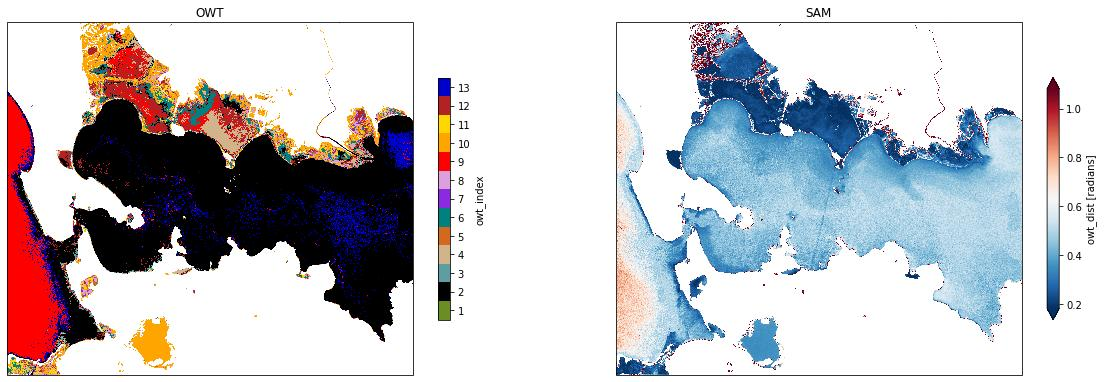

In [10]:
for iclass in range(3):
    fig = plt.figure(figsize=(20, 15))
    
    ax = plt.subplot(2, 2, 1, projection=proj)
    xowt_prod.owt_index.isel(Nclasses=iclass).plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)
    ax.set_title('OWT')
    cmap = plt.get_cmap('RdBu_r')#,13)
    ax = plt.subplot(2, 2, 2, projection=proj)
    xowt_prod.owt_dist.isel(Nclasses=iclass).plot.imshow(robust=True,cmap=cmap,ax=ax, cbar_kwargs={ 'shrink': 0.64})
    ax.set_title('SAM')

In [11]:

chla_ = GRSl2bgen.Chl(prod.raster,xowt_prod=xowt_prod)
chla = chla_.owt_blending(xowt_prod,Nclasses=1)

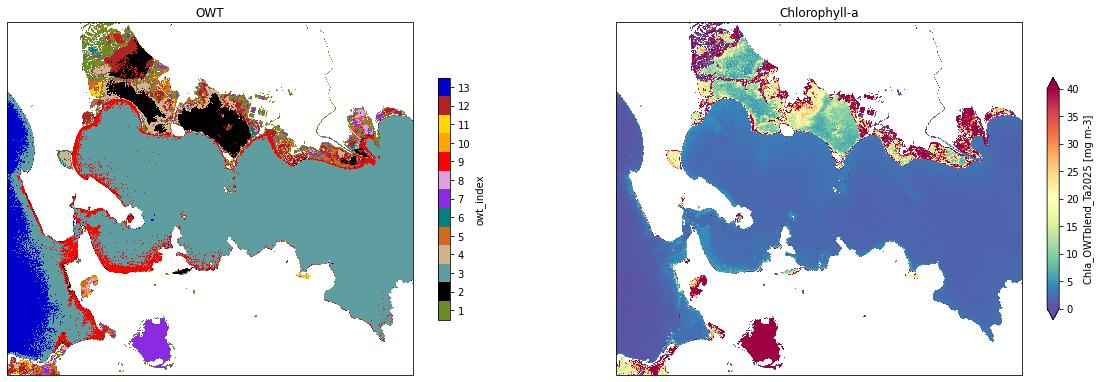

In [12]:
iclass=0
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.isel(Nclasses=iclass).plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)
ax.set_title('OWT')
cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
chla.plot.imshow(robust=True,vmin=0,vmax=40,cmap=plt.cm.Spectral_r,ax=ax, cbar_kwargs={ 'shrink': 0.64})
ax.set_title('Chlorophyll-a');

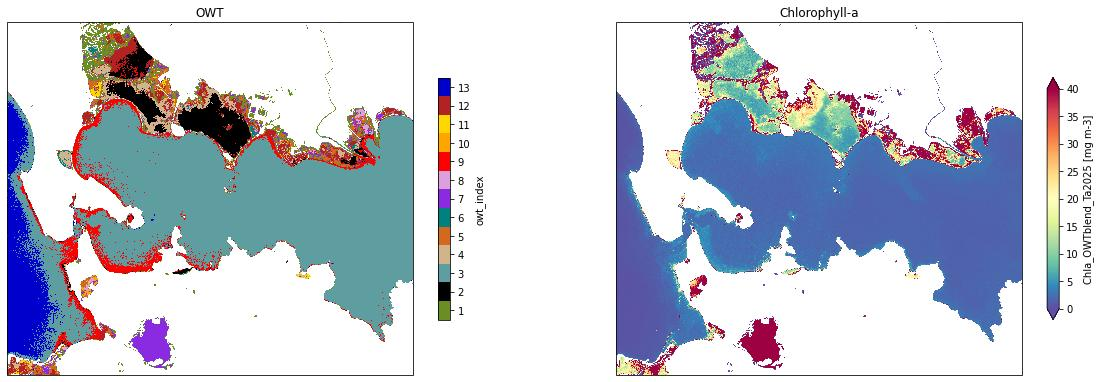

In [13]:
chla_ = GRSl2bgen.Chl(prod.raster,xowt_prod=xowt_prod)
chla = chla_.owt_blending(xowt_prod,Nclasses=2)
iclass=0
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.isel(Nclasses=iclass).plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)
ax.set_title('OWT')
cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
chla.plot.imshow(robust=True,vmin=0,vmax=40,cmap=plt.cm.Spectral_r,ax=ax, cbar_kwargs={ 'shrink': 0.64})
ax.set_title('Chlorophyll-a');

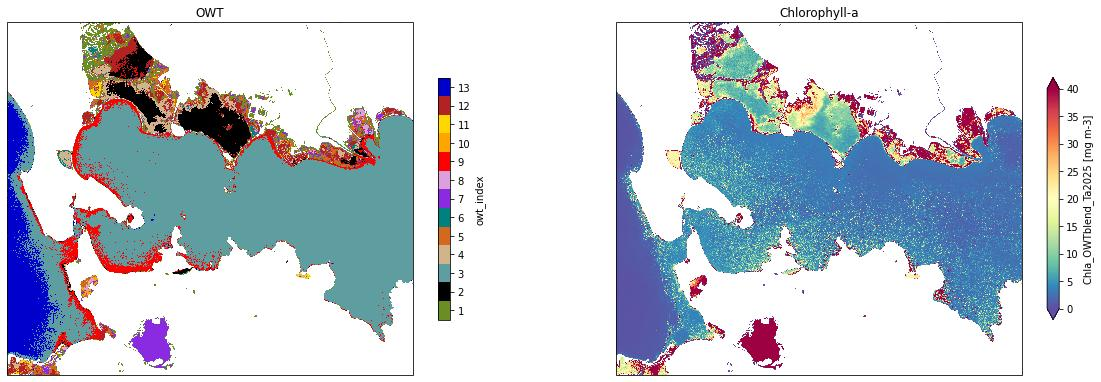

In [14]:
chla_ = GRSl2bgen.Chl(prod.raster,xowt_prod=xowt_prod)
chla = chla_.owt_blending(xowt_prod,Nclasses=3)
iclass=0
fig = plt.figure(figsize=(20, 15))

ax = plt.subplot(2, 2, 1, projection=proj)
xowt_prod.owt_index.isel(Nclasses=iclass).plot.imshow(vmin=0.5,vmax=OWT.Nowt+.5,cmap=OWT.cmap_owt,cbar_kwargs={ 'ticks':range(1,OWT.Nowt+1),'shrink': 0.64},ax=ax)
ax.set_title('OWT')
cmap = plt.get_cmap('RdBu_r')#,13)
ax = plt.subplot(2, 2, 2, projection=proj)
chla.plot.imshow(robust=True,vmin=0,vmax=40,cmap=plt.cm.Spectral_r,ax=ax, cbar_kwargs={ 'shrink': 0.64})
ax.set_title('Chlorophyll-a');

In [15]:
# ---------------------------------------------------
# get your Rrs image
# ---------------------------------------------------
Rrs_img = prod.raster.Rrs

In [16]:
# ---------------------------------------------------
# set number of top OWT classes to be used
# ---------------------------------------------------
Nclasses=2

In [17]:
# ---------------------------------------------------
# get your OWT classification product
# ---------------------------------------------------
OWT = GRSl2bgen.OWT(prod.raster,
                    owt_database='Spyrakos2018',Nclasses_to_be_saved=Nclasses)
xowt_prod = OWT.multi_process()

In [18]:
# ---------------------------------------------------
# get GRSl2bgen object for Chl-a computation
# ---------------------------------------------------
chl_process = GRSl2bgen.Chl(prod.raster)

In [19]:
# ---------------------------------------------------
# set number of top OWT classes to be used for algorithm weighting
# ---------------------------------------------------
Nclasses = np.min([len(xowt_prod.Nclasses), Nclasses])
xowt_prod = xowt_prod.isel(Nclasses=range(Nclasses))

In [20]:
eps = 1e-6

# ---------------------------------------------------
# Compute norm from owt SAM distance for each pixel
# ---------------------------------------------------
norm = 1 / (xowt_prod.owt_dist + eps)
# the summation assumes nan identical to 0
norm = norm.sum('Nclasses')
# replace empty value from 0 to nan
norm = norm.where(norm > 0)

In [21]:
# ---------------------------------------------------
# Recipe and algorithm application
# ---------------------------------------------------
# OWT 1, 6, 10: Gons
owt_index_to_keep = [1, 6, 10]
mask = chl_process.create_mask_from_owt(xowt_prod.owt_index, owt_index_to_keep)
weights = 1 / (xowt_prod.owt_dist.where(mask) + eps)
chla = (chl_process.chl_gons(Rrs_img.where(mask)) * weights).fillna(0)

# OWT 2, 4, 5, 11, 12 : NDCI
owt_index_to_keep = [2, 4, 5, 11, 12]
mask = chl_process.create_mask_from_owt(xowt_prod.owt_index, owt_index_to_keep)
weights = 1 / (xowt_prod.owt_dist.where(mask) + eps)
chla += (chl_process.chl_ndci(Rrs_img.where(mask)) * weights).fillna(0)

# OWT 7, 8 : Gilerson2
owt_index_to_keep = [7, 8]
mask = chl_process.create_mask_from_owt(xowt_prod.owt_index, owt_index_to_keep)
weights = 1 / (xowt_prod.owt_dist.where(mask) + eps)
chla += (chl_process.chl_gilerson2(Rrs_img.where(mask)) * weights).fillna(0)

# OWT 3, 9 ,13: OC2 for clear waters
owt_index_to_keep = [3, 9, 13]
mask = chl_process.create_mask_from_owt(xowt_prod.owt_index, owt_index_to_keep)
weights = 1 / (xowt_prod.owt_dist.where(mask) + eps)
acoef = [0.2236, -1.8296, 1.9094, -2.9481, -0.1718]
chla += (chl_process.OC2(Rrs_img.where(mask), acoef) * weights).fillna(0)

# get final product after normalization
chla = chla.sum('Nclasses') / norm

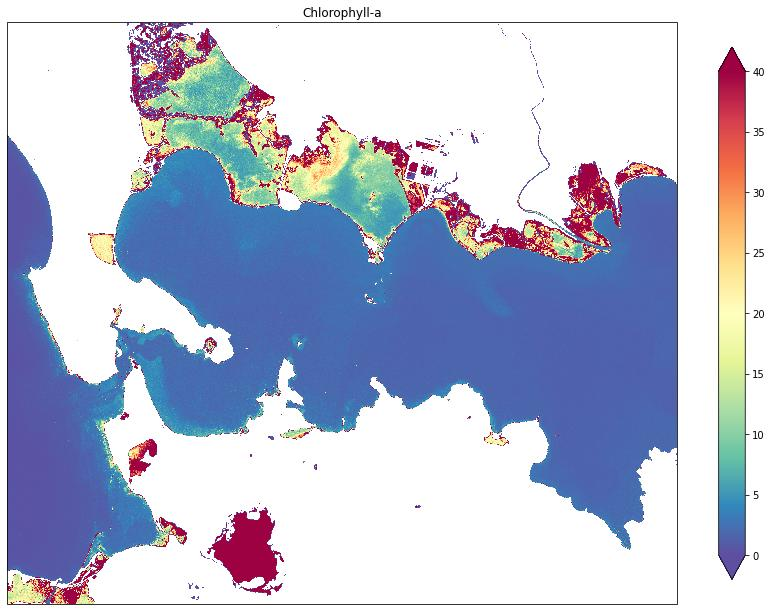

In [22]:
fig = plt.figure(figsize=(15, 15))

ax = plt.subplot( projection=proj)
chla.plot.imshow(robust=True,vmin=0,vmax=40,cmap=plt.cm.Spectral_r,ax=ax, cbar_kwargs={ 'shrink': 0.64})
ax.set_title('Chlorophyll-a');